# EIS Simulation with PyBaMM-EIS

This notebook demonstrates how to perform Electrochemical Impedance Spectroscopy (EIS) simulation using PyBaMM-EIS.

## Overview
- **Cell**: Tesla Model 3 Prismatic 160Ah NMC
- **Chemistry**: NMC811 (Nickel Manganese Cobalt)
- **Form Factor**: Prismatic
- **Simulations**: EIS at multiple SOC levels

In [1]:
# Import required libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_eis, nyquist_plot, bode_plot

## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [2]:
# Load cell manifest
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
material_path = Path("../materials")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
    # Load material data for separator and electrolyte
    for component in ["separator", "electrolyte"]:
        print(f"Loading material data for {component}")
        material_name = cell_design_manifest["cell_design"][component]["material"]["type"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

    # Load material data for electrodes
    for component in ["negative_electrode", "positive_electrode"]:
        print(f"Loading material data for {component}")
        material_name = cell_design_manifest["cell_design"][component]["coating"]["formulation"]["primary_active_material"]["name"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

# ============================================================================
# FITTED PARAMETERS FROM EXPERIMENTAL DATA
# ============================================================================
cell_design_manifest["cell_design"]["negative_electrode"]["coating"]["bruggeman_coefficient"] = {
    "value": 1.5,
    "unit": "1"
}
cell_design_manifest["cell_design"]["positive_electrode"]["coating"]["bruggeman_coefficient"] = {
    "value": 1.5,
    "unit": "1"
}

print(f"\nCell: {cell_design_manifest['metadata']['name']}")
print(f"Capacity: {cell_design_manifest['kpis']['nominal_capacity']['value']} Ah")

Loading material data for separator
Loading material data for electrolyte
Loading material data for negative_electrode
Loading material data for positive_electrode

Cell: Tesla Model3 Prismatic 160Ah
Capacity: 161.099 Ah


## 2. Run EIS Simulation at Single SOC

First, let's run a single EIS simulation at 50% SOC to understand the impedance spectrum.

In [3]:
# EIS configuration for single SOC
eis_config = {
    "frequencies": np.logspace(-2, 4, 50),  # 0.01 Hz to 10 kHz
    "soc": 0.5,  # 50% SOC
    "temperature_K": 298.15,  # 25°C
    "method": "direct",
    "contact_resistance": 0.0001,
}

result = run_eis(cell_design_manifest=cell_design_manifest, eis_config=eis_config)


EIS SIMULATION
Frequency range: 1.00e-02 - 1.00e+04 Hz
Number of frequencies: 50
SOC: 50.0%
Temperature: 25.0°C
Method: direct

Building EIS parameters from manifest...
  SOC: 50.0%
  Positive stoichiometry: 0.5000
  Negative stoichiometry: 0.5249
  Parameters loaded

Building EIS model...
Solving EIS at SOC = 50.0%...
  Completed: 50 frequency points
  Z at 1 Hz: 0.0004 + -0.0000j Ohm

EIS SIMULATION COMPLETE


In [4]:
# Display impedance summary
if result["success"]:
    print("\nEIS Results Summary:")
    print(f"  Frequency range: {result['frequencies_Hz'].min():.2e} - {result['frequencies_Hz'].max():.2e} Hz")
    print(f"  Number of points: {len(result['frequencies_Hz'])}")
    print(f"  Z at 0.1 Hz: {np.interp(0.1, result['frequencies_Hz'], result['Z_real']):.4f} + "
          f"{np.interp(0.1, result['frequencies_Hz'], result['Z_imag']):.4f}j Ω")
    print(f"  Z at 1 Hz: {np.interp(1.0, result['frequencies_Hz'], result['Z_real']):.4f} + "
          f"{np.interp(1.0, result['frequencies_Hz'], result['Z_imag']):.4f}j Ω")
    print(f"  Z at 1 kHz: {np.interp(1000, result['frequencies_Hz'], result['Z_real']):.4f} + "
          f"{np.interp(1000, result['frequencies_Hz'], result['Z_imag']):.4f}j Ω")
else:
    print(f"Simulation failed: {result.get('error', 'Unknown error')}")


EIS Results Summary:
  Frequency range: 1.00e-02 - 1.00e+04 Hz
  Number of points: 50
  Z at 0.1 Hz: 0.0004 + -0.0000j Ω
  Z at 1 Hz: 0.0004 + -0.0000j Ω
  Z at 1 kHz: 0.0001 + -0.0000j Ω


## 3. Visualize Single SOC Results

Create Nyquist and Bode plots for the impedance spectrum.

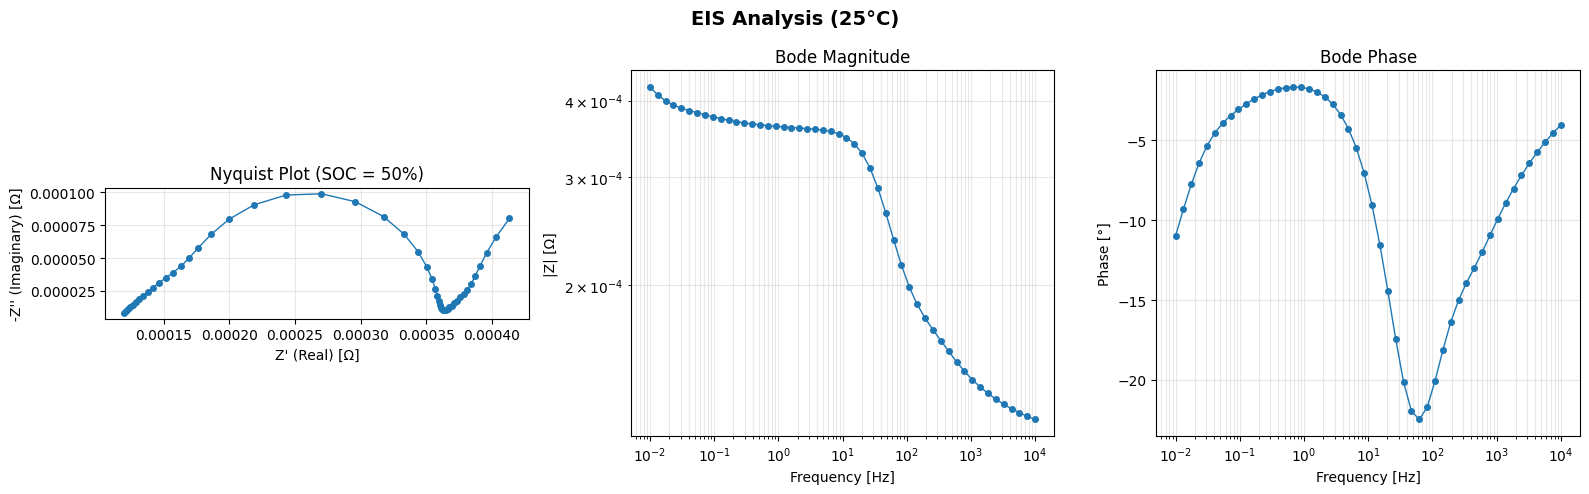

In [5]:
if result["success"]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Nyquist plot
    ax1 = axes[0]
    ax1.plot(result["Z_real"], -result["Z_imag"], 'o-', markersize=4, linewidth=1)
    ax1.set_xlabel("Z' (Real) [Ω]")
    ax1.set_ylabel("-Z'' (Imaginary) [Ω]")
    ax1.set_title(f"Nyquist Plot (SOC = {result['soc']*100:.0f}%)")
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Bode magnitude plot
    ax2 = axes[1]
    ax2.loglog(result["frequencies_Hz"], result["Z_magnitude"], 'o-', markersize=4, linewidth=1)
    ax2.set_xlabel("Frequency [Hz]")
    ax2.set_ylabel("|Z| [Ω]")
    ax2.set_title("Bode Magnitude")
    ax2.grid(True, alpha=0.3, which='both')
    
    # Bode phase plot
    ax3 = axes[2]
    ax3.semilogx(result["frequencies_Hz"], result["Z_phase_deg"], 'o-', markersize=4, linewidth=1)
    ax3.set_xlabel("Frequency [Hz]")
    ax3.set_ylabel("Phase [°]")
    ax3.set_title("Bode Phase")
    ax3.grid(True, alpha=0.3, which='both')
    
    plt.suptitle(f'EIS Analysis ({eis_config["temperature_K"]-273.15:.0f}°C)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot.")

## 4. Run EIS at Multiple SOC Levels

Now let's run EIS simulations at multiple SOC levels to see how impedance varies with state of charge.

In [6]:
# Run EIS at multiple SOC levels
soc_levels = [0.2, 0.4, 0.6, 0.8]
frequencies = np.logspace(-2, 4, 40)  # Fewer points for faster computation

eis_results = []
for soc in soc_levels:
    print(f"\n{'='*60}")
    print(f"Running EIS at SOC = {soc*100:.0f}%")
    print(f"{'='*60}")
    
    config = {
        "frequencies": frequencies,
        "soc": soc,
        "temperature_K": 298.15,
        "method": "direct",
        "contact_resistance": 0.0001,
    }
    
    result = run_eis(cell_design_manifest=cell_design_manifest, eis_config=config)
    eis_results.append(result)

print(f"\n\nCompleted {len([r for r in eis_results if r['success']])}/{len(soc_levels)} simulations")


Running EIS at SOC = 20%

EIS SIMULATION
Frequency range: 1.00e-02 - 1.00e+04 Hz
Number of frequencies: 40
SOC: 20.0%
Temperature: 25.0°C
Method: direct

Building EIS parameters from manifest...
  SOC: 20.0%
  Positive stoichiometry: 0.7994
  Negative stoichiometry: 0.2423
  Parameters loaded

Building EIS model...
Solving EIS at SOC = 20.0%...
  Completed: 40 frequency points
  Z at 1 Hz: 0.0004 + -0.0000j Ohm

EIS SIMULATION COMPLETE

Running EIS at SOC = 40%

EIS SIMULATION
Frequency range: 1.00e-02 - 1.00e+04 Hz
Number of frequencies: 40
SOC: 40.0%
Temperature: 25.0°C
Method: direct

Building EIS parameters from manifest...
  SOC: 40.0%
  Positive stoichiometry: 0.5998
  Negative stoichiometry: 0.4307
  Parameters loaded

Building EIS model...
Solving EIS at SOC = 40.0%...
  Completed: 40 frequency points
  Z at 1 Hz: 0.0004 + -0.0000j Ohm

EIS SIMULATION COMPLETE

Running EIS at SOC = 60%

EIS SIMULATION
Frequency range: 1.00e-02 - 1.00e+04 Hz
Number of frequencies: 40
SOC: 60.0%

## 5. Compare Impedance at Different SOC Levels

In [7]:
# Post-processing: Extract key metrics at each SOC
successful_results = [r for r in eis_results if r['success']]

if successful_results:
    metrics = []
    for r in successful_results:
        # Extract characteristic impedance values
        Z_1Hz = complex(np.interp(1.0, r['frequencies_Hz'], r['Z_real']),
                       np.interp(1.0, r['frequencies_Hz'], r['Z_imag']))
        Z_1kHz = complex(np.interp(1000, r['frequencies_Hz'], r['Z_real']),
                        np.interp(1000, r['frequencies_Hz'], r['Z_imag']))
        
        # Find minimum imaginary impedance (semicircle bottom)
        min_imag_idx = np.argmin(r['Z_imag'])
        
        metrics.append({
            'SOC [%]': f"{r['soc']*100:.0f}",
            'Z @ 1Hz [mΩ]': f"{abs(Z_1Hz)*1000:.2f}",
            'Z @ 1kHz [mΩ]': f"{abs(Z_1kHz)*1000:.2f}",
            'R_ohmic [mΩ]': f"{r['Z_real'].min()*1000:.2f}",
        })
    
    summary_df = pd.DataFrame(metrics)
    print("\nEIS Summary at Different SOC Levels:")
    print(summary_df.to_string(index=False))


EIS Summary at Different SOC Levels:
SOC [%] Z @ 1Hz [mΩ] Z @ 1kHz [mΩ] R_ohmic [mΩ]
     20         0.41          0.14         0.12
     40         0.36          0.14         0.12
     60         0.36          0.14         0.12
     80         0.41          0.14         0.12


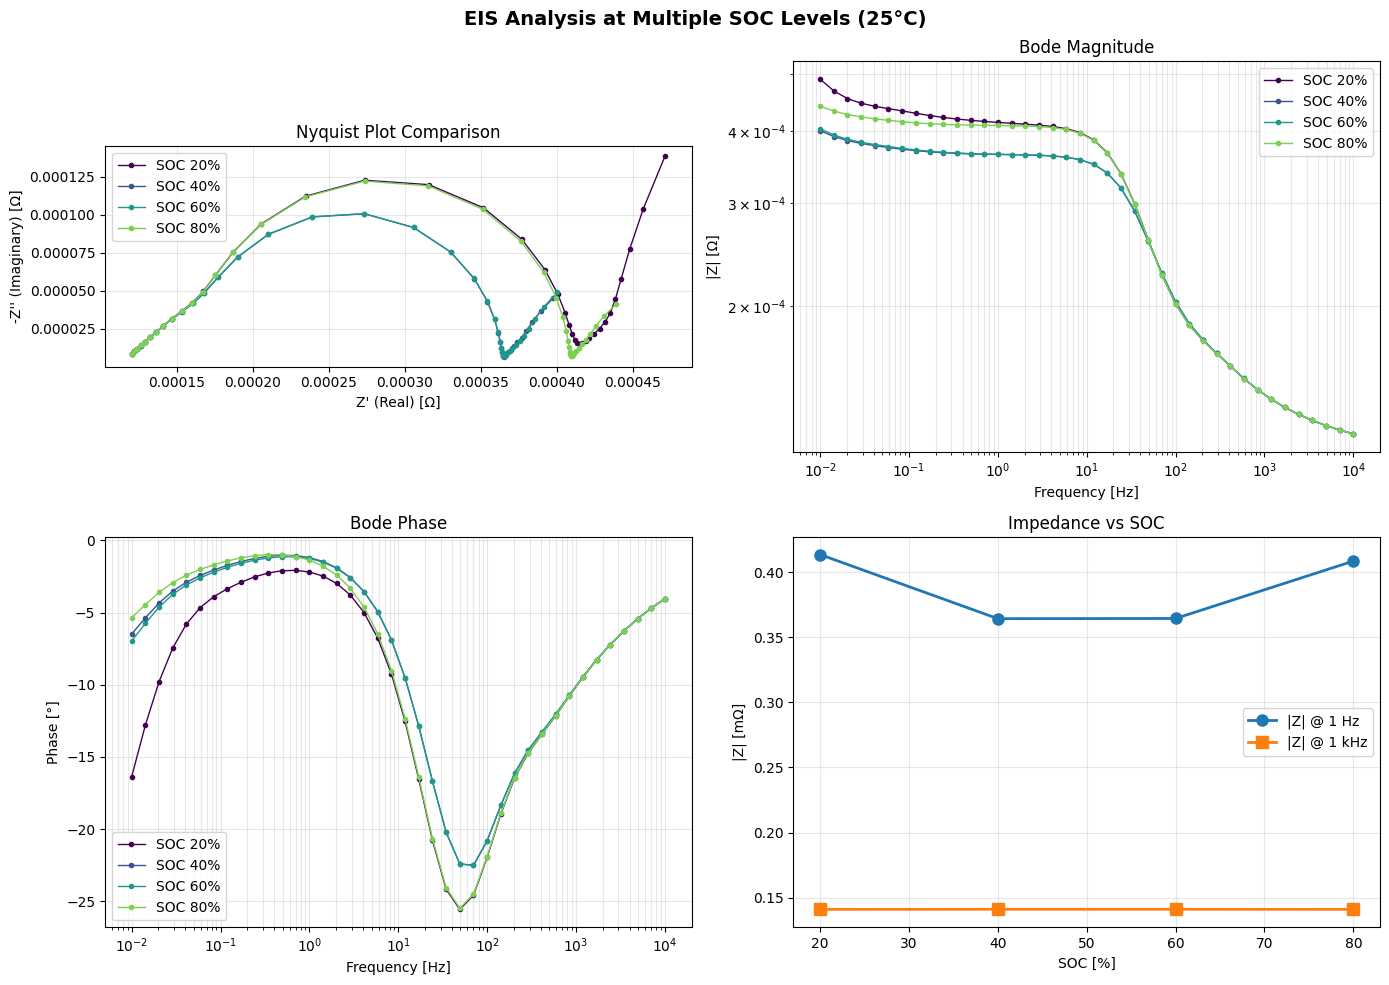

In [8]:
# Plot comparison
if len(successful_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(successful_results)))
    
    # Plot 1: Nyquist comparison
    ax1 = axes[0, 0]
    for i, r in enumerate(successful_results):
        ax1.plot(r['Z_real'], -r['Z_imag'], 'o-', markersize=3, linewidth=1,
                 color=colors[i], label=f"SOC {r['soc']*100:.0f}%")
    ax1.set_xlabel("Z' (Real) [Ω]")
    ax1.set_ylabel("-Z'' (Imaginary) [Ω]")
    ax1.set_title("Nyquist Plot Comparison")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Plot 2: Bode magnitude comparison
    ax2 = axes[0, 1]
    for i, r in enumerate(successful_results):
        ax2.loglog(r['frequencies_Hz'], r['Z_magnitude'], 'o-', markersize=3, linewidth=1,
                   color=colors[i], label=f"SOC {r['soc']*100:.0f}%")
    ax2.set_xlabel("Frequency [Hz]")
    ax2.set_ylabel("|Z| [Ω]")
    ax2.set_title("Bode Magnitude")
    ax2.legend()
    ax2.grid(True, alpha=0.3, which='both')
    
    # Plot 3: Bode phase comparison
    ax3 = axes[1, 0]
    for i, r in enumerate(successful_results):
        ax3.semilogx(r['frequencies_Hz'], r['Z_phase_deg'], 'o-', markersize=3, linewidth=1,
                     color=colors[i], label=f"SOC {r['soc']*100:.0f}%")
    ax3.set_xlabel("Frequency [Hz]")
    ax3.set_ylabel("Phase [°]")
    ax3.set_title("Bode Phase")
    ax3.legend()
    ax3.grid(True, alpha=0.3, which='both')
    
    # Plot 4: Impedance vs SOC at characteristic frequencies
    ax4 = axes[1, 1]
    socs = [r['soc']*100 for r in successful_results]
    Z_1Hz = [abs(complex(np.interp(1.0, r['frequencies_Hz'], r['Z_real']),
                        np.interp(1.0, r['frequencies_Hz'], r['Z_imag'])))*1000 
             for r in successful_results]
    Z_1kHz = [abs(complex(np.interp(1000, r['frequencies_Hz'], r['Z_real']),
                         np.interp(1000, r['frequencies_Hz'], r['Z_imag'])))*1000 
              for r in successful_results]
    
    ax4.plot(socs, Z_1Hz, 'o-', markersize=8, linewidth=2, label='|Z| @ 1 Hz')
    ax4.plot(socs, Z_1kHz, 's-', markersize=8, linewidth=2, label='|Z| @ 1 kHz')
    ax4.set_xlabel("SOC [%]")
    ax4.set_ylabel("|Z| [mΩ]")
    ax4.set_title("Impedance vs SOC")
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle('EIS Analysis at Multiple SOC Levels (25°C)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No successful simulations to plot.")

## 6. Export Results

Export the EIS data to CSV for further analysis.

In [9]:
# Export results to CSV
if len(successful_results) > 0:
    for r in successful_results:
        df = pd.DataFrame({
            'Frequency_Hz': r['frequencies_Hz'],
            'Z_real_Ohm': r['Z_real'],
            'Z_imag_Ohm': r['Z_imag'],
            'Z_magnitude_Ohm': r['Z_magnitude'],
            'Z_phase_deg': r['Z_phase_deg'],
        })
        filename = f"eis_soc_{r['soc']*100:.0f}pct.csv"
        # df.to_csv(filename, index=False)
        print(f"Would export: {filename} ({len(df)} rows)")
    
    print("\nTo save, uncomment the df.to_csv() line above.")

Would export: eis_soc_20pct.csv (40 rows)
Would export: eis_soc_40pct.csv (40 rows)
Would export: eis_soc_60pct.csv (40 rows)
Would export: eis_soc_80pct.csv (40 rows)

To save, uncomment the df.to_csv() line above.
